In [1]:
from hcipy import *
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
from matplotlib.animation import FFMpegWriter
from tqdm.notebook import tqdm
import astropy.io.fits as fits
from pathlib import Path, PosixPath
import math
from scipy.interpolate import interp1d
from speclite import filters
import scipy.integrate as integrate
from shackhartmann import MySquareShackHartmannWavefrontSensorOptics
from transmitted_power import transmitted_power
from csv import DictWriter
from noisydetector import MyNoisyDetector, MyNoiselessDetector
from extended_source import make_multiple_sources

In [2]:
# some telescope parameters

telescope_diameter = 0.8 #m
focal_length = 5.6 #m
platescale = 206265 / focal_length #arcsec/m
fov_sci = 2 # arcsec

spider_width = 0.02 # m this is a guess
num_spiders = 4
central_obscuration = 0.1558 # meter
central_obscuration_ratio = central_obscuration / telescope_diameter
oversizing_factor = 16 / 16
area_aperture = math.pi*(telescope_diameter/2)**2 - math.pi*(central_obscuration/2)**2 - (telescope_diameter-central_obscuration)*spider_width*num_spiders # m^2

num_pupil_pixels = 100 * oversizing_factor
pupil_diameter = telescope_diameter * oversizing_factor

In [3]:
# transmission loss parameters

n_telescope_mirrors = 3
n_ao_mirrors = 7

target_spectrum_file = Path('LEO_spectrum.fits') # can be .fits or .csv
telescope_coating_file = Path('protected_aluminium_reflectance.csv') #microns
ao_coating_file = Path('protected_aluminium_reflectance.csv')
qe_file = Path('qe_curve.csv') # angstr; asked ChatGPT to make arrays from an image of QE curve for Oxford Instr. OCAM2K camera 

wfs_spectral_band = 'r'
wfs_filter = filters.load_filter(f'sdss2010-{wfs_spectral_band}')

In [4]:
# make a telescope pupil

pupil_grid = make_pupil_grid(num_pupil_pixels, diameter=pupil_diameter)
pupil_aperture_generator = make_obstructed_circular_aperture(telescope_diameter, 
                                                             central_obscuration_ratio, 
                                                             num_spiders=num_spiders, 
                                                             spider_width=spider_width)
telescope_pupil = evaluate_supersampled(pupil_aperture_generator, pupil_grid, 4)

In [16]:
wavelengths = [[6000e-10], [6000e-10]] # meters
off_axis_angle = [0, 2] # arcsec 

wavefronts = make_multiple_sources(telescope_pupil, 
                                   off_axis_angle, 
                                   wavelengths)

In [17]:
# make focal plane
fov_sci = 5
spatial_res = wavelengths[0][0] * focal_length / telescope_diameter # all variables use meters
num_airy = fov_sci/platescale / spatial_res
sci_cam_px_size = 2.9e-6 # meters / px, assuming same pixel size as current LEO camera
q = math.ceil(spatial_res / sci_cam_px_size)
focal_grid = make_focal_grid(q=q, num_airy=num_airy, spatial_resolution=spatial_res)
# q = number of pixels between rings, num_airy = number of rings that should be visible

print(f"expected number of visible airy disks: {round(num_airy,1)}, expected spatial extent of focal plane: {round(spatial_res*num_airy/1e-6, 1)}µm")

expected number of visible airy disks: 32.3, expected spatial extent of focal plane: 135.7µm


In [18]:
prop = FraunhoferPropagator(pupil_grid, focal_grid, focal_length=focal_length)

In [19]:
psf_ref = 0

for i, wf in enumerate(wavefronts[:1]):

    prop_wf = prop.forward(wf)
    psf_ref += prop_wf.power
    
scaled_psf_ref = np.log10(psf_ref/psf_ref.max())

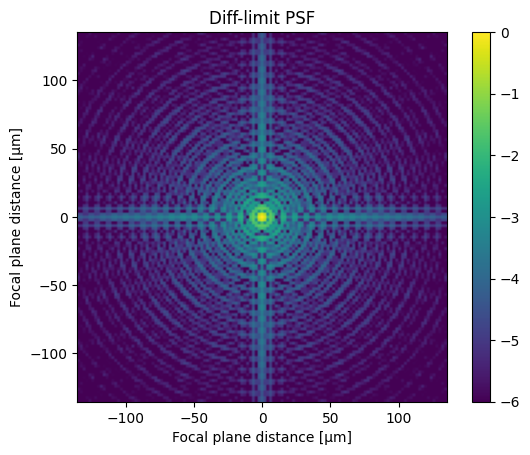

In [20]:
plt.title('Diff-limit PSF')
imshow_field(scaled_psf_ref, vmin = -6, vmax=0, grid_units=1e-6)
plt.xlabel('Focal plane distance [µm]')
plt.ylabel('Focal plane distance [µm]')
plt.colorbar()